<a href="https://colab.research.google.com/github/BlackFlag77/SE4050-DL-Lab-2/blob/main/MLP_with_MNIST_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot as plt

from tensorflow.keras import regularizers

import numpy as np


Load the MNIST dataset

In [65]:
(train_data,train_target),(test_data,test_target) = mnist.load_data()

Visualize the dataset

Target labels:  [3 4 4 4 1 7 4 8 5 0]


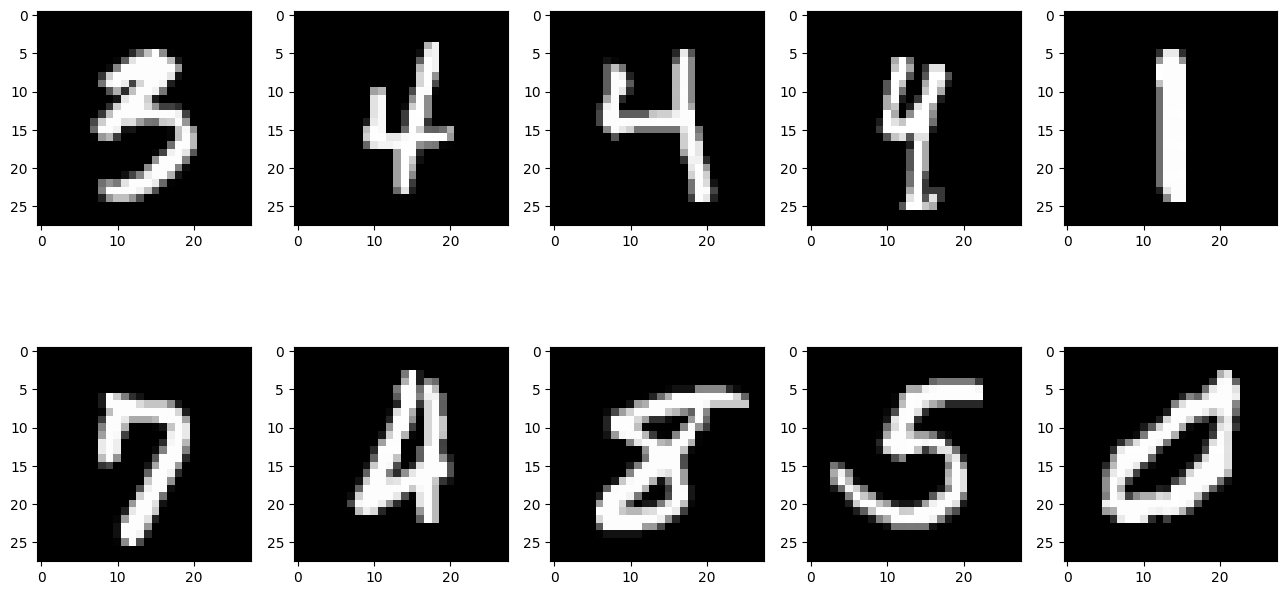

In [66]:
fig, axs = plt.subplots(2, 5, figsize=(16,8))
random_numbers = np.random.randint(0, 60000, 10)
print('Target labels: ',train_target[random_numbers])
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(train_data[random_numbers[idx]],cmap='gray')
plt.show()

Pre-processing stage

In [67]:
new_train_data = train_data/255.0
new_test_data=test_data/255.0

new_train_target = to_categorical(train_target)
new_test_target = to_categorical(test_target)

Create the Model architecture

In [68]:
model=Sequential()

model.add(Flatten(input_shape=(28,28)))

# model.add(Dense(64,activation='relu'))
# model.add(Dense(64,input_dim=64,activation='relu'))
# model.add(Dense(32,input_dim=64,activation='relu'))

# Task 3.A — Hyperparameter Tuning
# model.add(Dense(128,activation='relu'))
# model.add(Dense(128,input_dim=64,activation='relu'))
# model.add(Dense(64,input_dim=64,activation='relu'))

# Task 3.B — L1/L2 Regularization
model.add(Dense(128,activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dense(128,input_dim=64,activation='relu', kernel_regularizer=regularizers.l2(0.001)))
model.add(Dense(64,input_dim=64,activation='relu', kernel_regularizer=regularizers.l2(0.001)))

model.add(Dense(10,input_dim=32,activation='softmax'))
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

# Task 3.A — Conclusion

Increasing the number of epochs and modifying the network architecture did not improve the final test accuracy. This indicates that the original model was already well-tuned for the MNIST dataset, and additional complexity or longer training did not necessarily improve performance.

# Task 3.B — Conclusion

Adding L2 regularization slightly reduced the test accuracy while increasing the loss. This is expected because regularization penalizes large weights to reduce overfitting and improve the model's ability to generalize to unseen data.

In [69]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,898 (491.79 KB)

 Trainable params: 125,898 (491.79 KB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [70]:
# train_info = model.fit(new_train_data , new_train_target , epochs = 10, )
train_info = model.fit(new_train_data , new_train_target , epochs=20 , validation_split=0.2)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9164 - loss: 0.5223 - val_accuracy: 0.9615 - val_loss: 0.3313
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9577 - loss: 0.3134 - val_accuracy: 0.9628 - val_loss: 0.2780
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9654 - loss: 0.2596 - val_accuracy: 0.9650 - val_loss: 0.2541
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9675 - loss: 0.2354 - val_accuracy: 0.9670 - val_loss: 0.2347
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9694 - loss: 0.2176 - val_accuracy: 0.9589 - val_loss: 0.2437
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9706 - loss: 0.2112 - val_accuracy: 0.9679 - val_loss: 0.2164
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9726 - loss: 0.1991 - val_accuracy: 0.9681 - val_loss: 0.2131
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9729 - loss: 0.1934 

Plot the loss and accuracy graphs

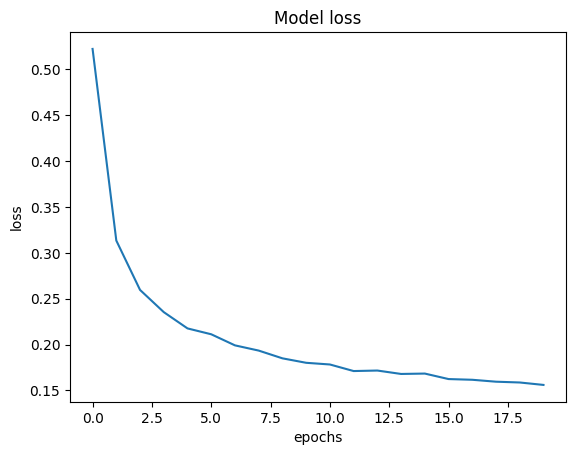

In [71]:
plt.plot(train_info.history['loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Model loss')
plt.show()

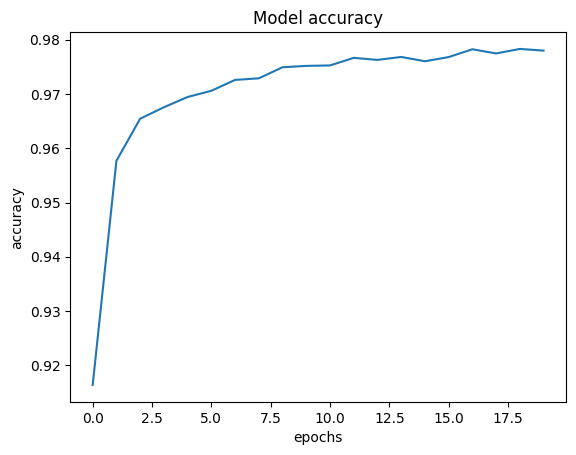

In [72]:
plt.plot(train_info.history['accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Model accuracy')
plt.show()

Test the performance of Model

In [73]:
loss, acc = model.evaluate(new_test_data , new_test_target)
print(f'Loss of the Test dataset is: {loss}\nAccuracy of the test dataset is: {acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9738 - loss: 0.1742
Loss of the Test dataset is: 0.17421109974384308
Accuracy of the test dataset is: 0.973800003528595


Save the model weights

In [74]:
# model.save_weights('MNIST_WEIGHTS_V1.h5')
model.save_weights('MNIST_WEIGHTS_V1.weights.h5')

Inspecting the file: MNIST_WEIGHTS_V1.weights.h5

In [75]:
import h5py

file_path = 'MNIST_WEIGHTS_V1.weights.h5'

print(f"Inspecting file: {file_path}")
with h5py.File(file_path, 'r') as f:
    # Print all top-level keys in the file
    print("\nTop-level keys in the HDF5 file:")
    for key in f.keys():
        print(f"- {key}")
        # If you want to inspect deeper, you can iterate through groups/datasets
        # For example, print attributes of a key (often layer names)
        item = f[key]
        if isinstance(item, h5py.Group):
            for sub_key in item.keys():
                print(f"  - {key}/{sub_key}")
                sub_item = item[sub_key]
                if isinstance(sub_item, h5py.Group):
                    for sub_sub_key in sub_item.keys():
                        print(f"    - {key}/{sub_key}/{sub_sub_key}")
                elif isinstance(sub_item, h5py.Dataset):
                    print(f"    (Dataset shape: {sub_item.shape})")
        elif isinstance(item, h5py.Dataset):
            print(f"  (Dataset shape: {item.shape})")

Inspecting file: MNIST_WEIGHTS_V1.weights.h5

Top-level keys in the HDF5 file:
- layers
  - layers/dense
    - layers/dense/vars
  - layers/dense_1
    - layers/dense_1/vars
  - layers/dense_2
    - layers/dense_2/vars
  - layers/dense_3
    - layers/dense_3/vars
  - layers/flatten
    - layers/flatten/vars
- optimizer
  - optimizer/vars
    - optimizer/vars/0
    - optimizer/vars/1
    - optimizer/vars/10
    - optimizer/vars/11
    - optimizer/vars/12
    - optimizer/vars/13
    - optimizer/vars/14
    - optimizer/vars/15
    - optimizer/vars/16
    - optimizer/vars/17
    - optimizer/vars/2
    - optimizer/vars/3
    - optimizer/vars/4
    - optimizer/vars/5
    - optimizer/vars/6
    - optimizer/vars/7
    - optimizer/vars/8
    - optimizer/vars/9
- vars


# Task 3.C — Confusion Matrix

The confusion matrix shows that most predictions are located along the main diagonal, indicating that the model correctly classified the majority of handwritten digits. Misclassifications mainly occurred between digits with similar handwritten appearances.

In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [79]:
predictions = model.predict(new_test_data)

predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(
    test_target,
    predicted_labels
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


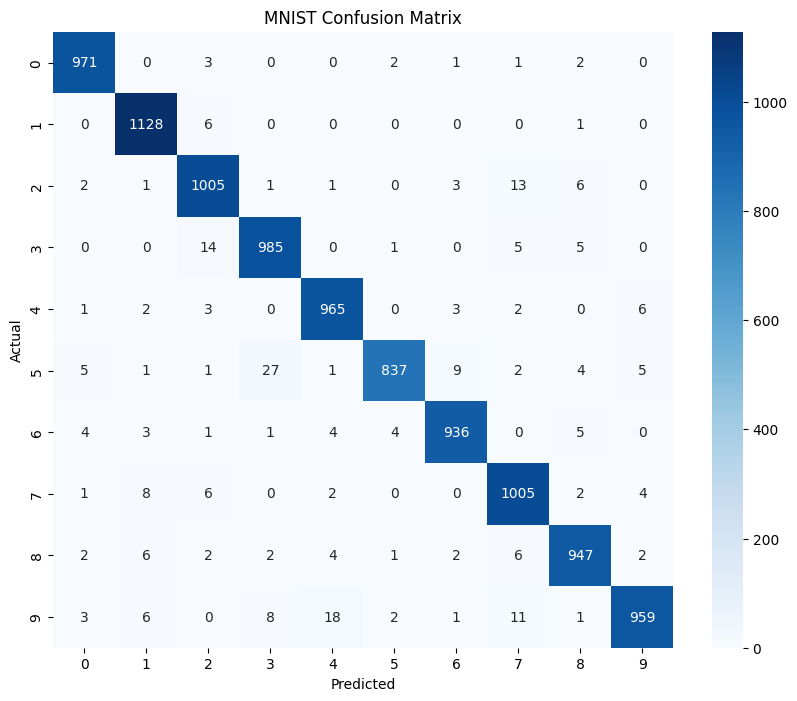

In [80]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNIST Confusion Matrix")

plt.show()